In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Let the data matrix be $X$ where each row is a sample with the columns being the features. We encode the classes as hot one vectors;
the truevalue matrix $y$ is then going to have a row for each sample with a 1 in a particular column indicating that associated class and 0 in the other columns.

Logistic regression is a classification method where given some properties, we aim to predict a category the object lies in.
In logistic regression the model consists of passing the data through a linear layer which is followed by the softmax. We represent the parameters using a matrix $W$ and $b$. $W$ are the weights for the linear layer and $b$ is the bias term. 

When inputting a vector $x$ into the softmax we have the following:
$$
\begin{gathered}
    softmax(x)_i=\frac{e^{x_i}}{\sum_{j} e^{x_j}}
    \\
\end{gathered}
$$
The softmax in particular results in the sum of the entries of the resulting vector to sum to one, hence we can interpret the output as a conditional probability distribution for the class given the features. The highest probability is then considered the most probably and hence predicted class.

Our loss function is the cross entropy loss:
$$
\begin{gathered}
L=-\sum_{i}^N \sum_{j}^k -y_j^{(i)}log(\hat{y}_j^{(i)})
\end{gathered}
$$ where $y_{j}^{(i)}$ and $\hat{y}_j^{(i)}$ are the jth entries of the ith samples.
This can be found by maximum likelihood estimation (we think of $\hat{y}^{(i)}$ as an approximation of the conditional distribution given the features of sample i and $y^{(i)}$ as the true 'distribution', this is 0 for all but one entry by nature). The likelihood is $P(\bold{Y}=Y|\bold{X}=X)$ where $Y$ is the true classes and $X$ are the given features, we find the negative log likelihood (so we now minimise) and proceed with MLE to get a non-averaged version of our loss function. We average over samples so that our learning rate can be independent of sample size.

Minimisation of this function has no closed form hence we use gradient descent.

Notably, when applying softmax followed by log, for large entries, the numbers can become very large.
$\\$
In practice for this case we would calculate the following:
$log(softmax(v))_i=v_i-logS$ where $S=\sum_{j} e^{v_j}$

When applying softmax to vectors with a large entry, exponentiating large values will result in even larger values. To avoid this we divide all terms in the softmax by $e^{v_{max}}$ where $v_{max}$ is the largest entry, this way results all the numbers being exponentiated being smaller and so easier to handle. This is infact the same as applying softmax to a vector where we have subtracted $v_{max}$ from each entry.

In [30]:
#Model
def vector_softmax(v):
    exp_v = np.exp(v - np.max(v))
    return exp_v / np.sum(exp_v)

def matrix_softmax(X):
    X_shifted = X - np.max(X, axis=1, keepdims=True)
    exp_X = np.exp(X_shifted)
    return exp_X / np.sum(exp_X, axis=1, keepdims=True)

def prediction(data,weights,bias):
    return data@weights+bias

def cross_entropy(label,prediction):
    return -np.mean(np.sum(label * np.log(matrix_softmax(prediction)), axis=1))

def logistic_regression(data,labels,iterations=10000,learning_rate=0.05):
    no_samples=np.shape(data)[0]
    no_features=np.shape(data)[1]
    no_categories=np.shape(labels)[1]
    weights=np.zeros((no_features,no_categories))
    bias=np.zeros(no_categories)
    wgrad=lambda W,b: 1/no_samples*data.T@(matrix_softmax(prediction(data,W,b))-labels) #Grad with respect to weights matrix
    bgrad=lambda W,b: np.mean(matrix_softmax(prediction(data,W,b))-labels,axis=0) #Grad with respect to bias vector
    loss=[]
    #Gradient descent
    for i in range(iterations):
        t1=wgrad(weights,bias)
        t2=bgrad(weights,bias)
        weights=weights-learning_rate*t1
        bias=bias-learning_rate*t2
        if i%100==0:
            cel=cross_entropy(labels,prediction(data,weights,bias))
            loss.append(cel)
    return weights,bias,loss

In [31]:
#Data preparation
training_data=pd.read_csv('phone_pricing_range_train.csv')
training_data["p0"] = (training_data["price_range"] == 0).astype(int) #Adding a column for each price range class
training_data["p1"] = (training_data["price_range"] == 1).astype(int)
training_data["p2"] = (training_data["price_range"] == 2).astype(int)
training_data["p3"] = (training_data["price_range"] == 3).astype(int)
features=np.array(training_data.drop(["p0","p1","p2","p3","price_range"],axis=1))
price_range=np.array(training_data[["p0","p1","p2","p3"]])
nonbinaryindex=np.where((features[0]!=0)&(features[0]!=1)) #Finding column indices of non binary features, I checked this manually
normalisedfeatures=np.array(training_data.drop(["p0","p1","p2","p3","price_range"],axis=1))
#Standardisation used to reduce chance of divergence or overflow during optimisation
columnmean=np.mean(normalisedfeatures[:,nonbinaryindex],axis=0)
columnstd=np.std(normalisedfeatures[:,nonbinaryindex],axis=0)
normalisedfeatures[:,nonbinaryindex]=(normalisedfeatures[:,nonbinaryindex]-columnmean)/columnstd

In [32]:
weights,bias,loss=logistic_regression(normalisedfeatures,price_range,learning_rate=0.35)

Below we have the loss curve which flattens confirming that we have began to converge.

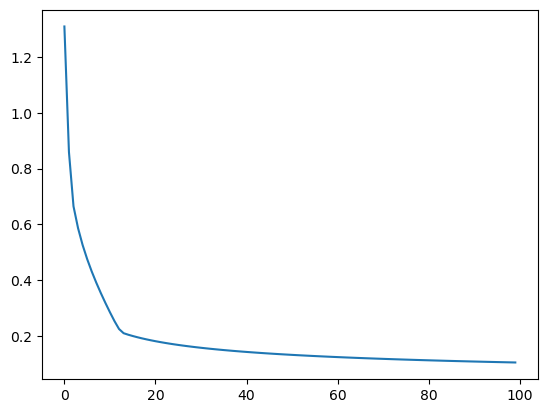

In [33]:
#Cross entropy loss during optimisation
plt.plot(range(len(loss)),loss)

The accuracy is just the proportion of prediction in which we were correct in the test set. 0.966 indicatves a very high proportion of our predictions were correct so the model seems to have worked.

In [34]:
test1data=pd.read_csv('test1.csv')
test1data['p0']=(test1data['price_range']==0).astype(int)
test1data['p1']=(test1data['price_range']==1).astype(int)
test1data['p2']=(test1data['price_range']==2).astype(int)
test1data['p3']=(test1data['price_range']==3).astype(int)
normalised=np.array(test1data.drop(["p0","p1","p2","p3","price_range"],axis=1))
normalised[:,nonbinaryindex]=(normalised[:,nonbinaryindex]-columnmean)/columnstd
testprice=test1data[["p0","p1","p2","p3"]]
pred=prediction(normalised,weights,bias)
accuracy=(np.argmax(pred,axis=1)==np.argmax(testprice,axis=1)).mean()
print(accuracy)

0.9659863945578231
